In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

# **Data Pre-Processing::**

In [3]:
df = pd.read_csv("/content/Mall_Customers.csv")

In [4]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [5]:
df = df.iloc[:,[1,2,3,4]]

In [6]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [8]:
df.describe()

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [9]:
df.dtypes
sns.set_theme()
sns.set_style("dark")

In [10]:
df.shape

(200, 4)

# **EDA**

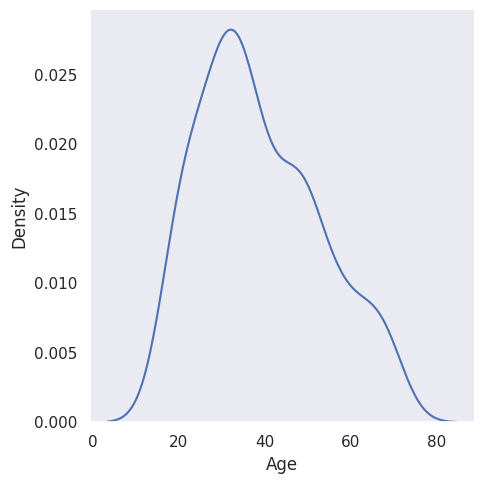

In [11]:
sns.displot(df,x="Age",kind="kde")

In [12]:

df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

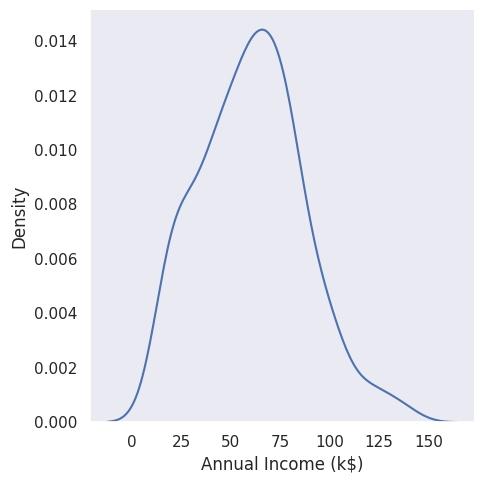

In [13]:
sns.displot(df,x="Annual Income (k$)",kind="kde")

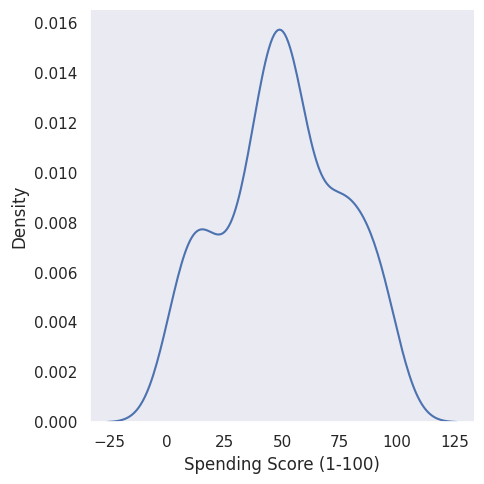

In [14]:
sns.displot(df,x="Spending Score (1-100)",kind="kde")

<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

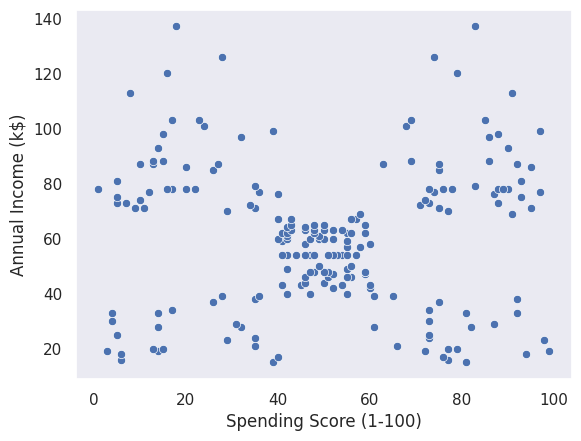

In [15]:
sns.scatterplot(df,x="Spending Score (1-100)",y="Annual Income (k$)")

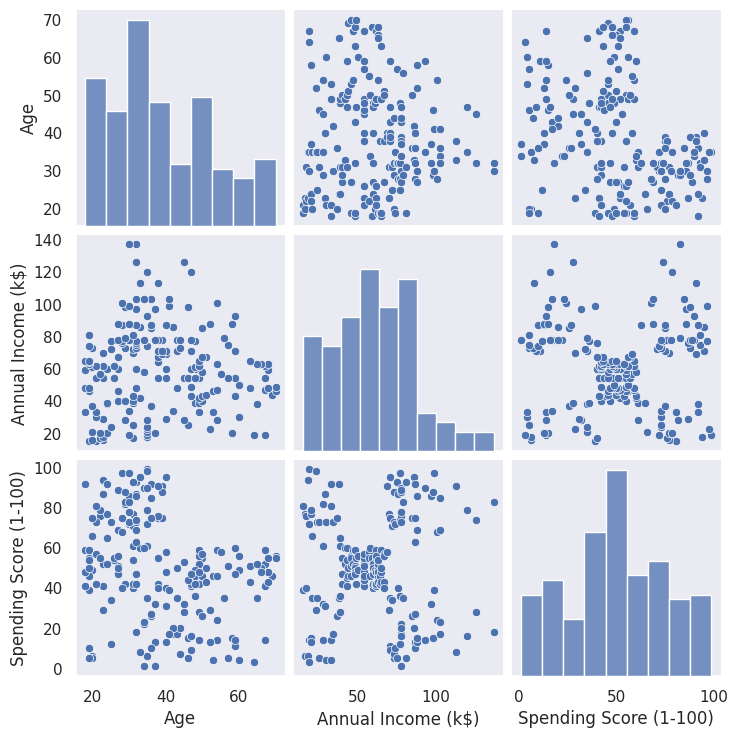

In [16]:
sns.pairplot(df)

# **MODEL TRAINING AND EVLAUATION**

We use encoding method to convert genders into numeric values

In [22]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

/tmp/ipykernel_5759/98949673.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})


In [23]:
df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

we use standard scaler to make data distribution even for better results

In [119]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Use only 2 columns
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

In [120]:
df.describe()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,0.560000,38.850000,60.560000,50.200000,1.755000
std,0.497633,13.969007,26.264721,25.823522,1.468249
min,0.000000,18.000000,15.000000,1.000000,0.000000
25%,0.000000,28.750000,41.500000,34.750000,0.000000
50%,1.000000,36.000000,61.500000,50.000000,2.000000
75%,1.000000,49.000000,78.000000,73.000000,3.000000
max,1.000000,70.000000,137.000000,99.000000,4.000000


Inertia measures how compact the clusters are by calculating the total distance between each data point and its assigned cluster centroid. A lower inertia value indicates that the data points are closer to their respective cluster centers, resulting in more cohesive and well-defined clusters.

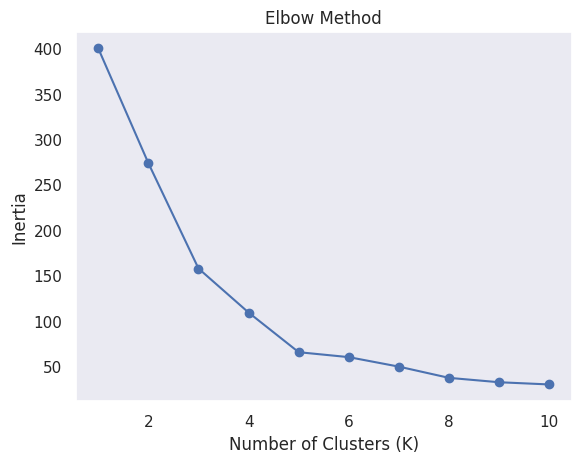

In [121]:


inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The silhouette score evaluates the quality of clustering by measuring how well each data point fits within its assigned cluster compared to other clusters. It considers both cluster cohesion and separation, with values ranging from -1 to 1. A higher silhouette score indicates better-defined and well-separated clusters.

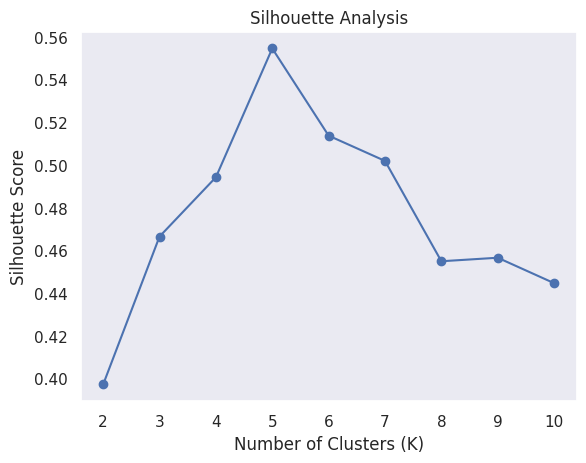

In [122]:
from sklearn.metrics import silhouette_score

sil_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [124]:
# X_plot = X_scaled[:, [1, 2]]


kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(X_scaled)

KMeans(n_clusters=5, random_state=42)

Intial plotting of kmeans we trained on income and spending score


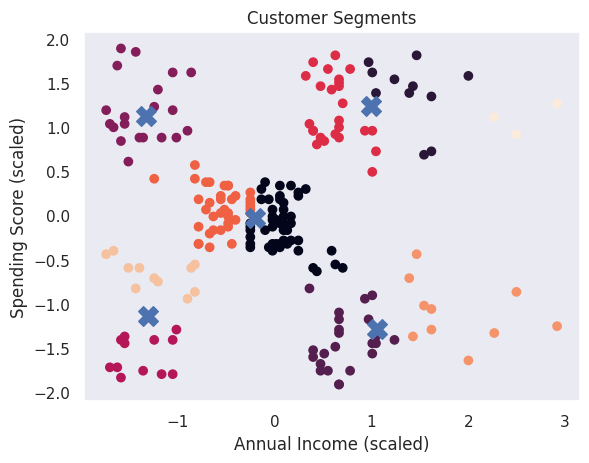

In [126]:
import matplotlib.pyplot as plt

X_plot = X_scaled # Income & Spending Score

plt.scatter(X_plot[:, 0], X_plot[:, 1], c=labels)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=200, marker='X')

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segments")
plt.show()

In [127]:
summary = df.groupby('Cluster').mean()
print(summary)

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.568966  55.275862           47.620690               41.706897
1        0.550000  32.875000           86.100000               81.525000
2        0.576923  25.769231           26.115385               74.846154
3        0.600000  26.733333           54.311111               40.911111
4        0.483871  44.387097           89.774194               18.483871


**Cluster 0: Average Customers
Explanation: Moderate income and spending. These represent the general customer base.**

**Cluster 1: Premium Customers
Explanation: High income and high spending behavior. These are the most valuable customers and should be targeted for premium services.**

**Cluster 2: Impulsive Customers
Explanation: Low income but high spending. These customers tend to spend more despite limited income.**

**Cluster 3: Average Customers
Explanation: Moderate income and spending. These represent the general customer base.**

**Cluster 4: Conservative Customers
Explanation: High income but low spending. These customers have potential but are not actively spending.**

More clear diagram of Kmeans clustring distribution with customer segmentataion

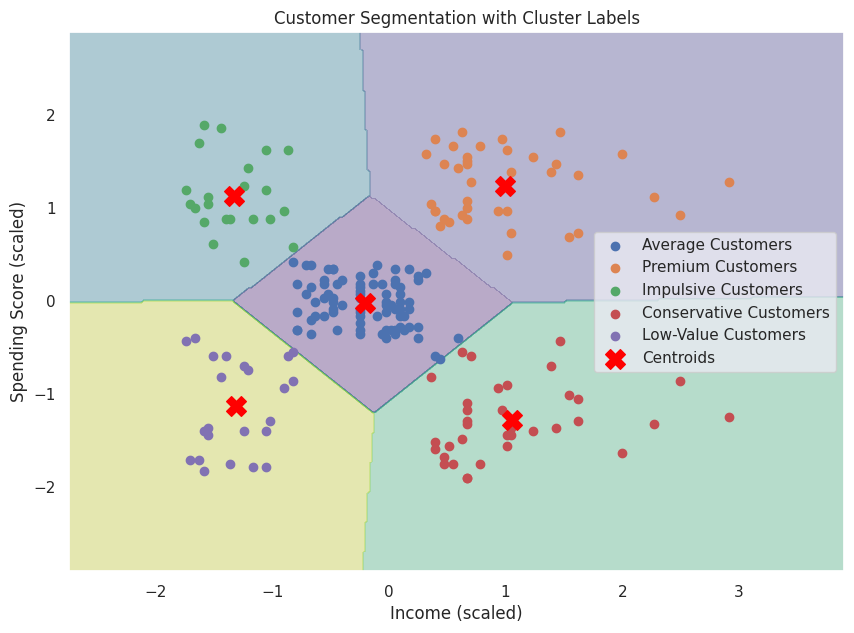

In [128]:



# Create dataframe for interpretation
df_temp = pd.DataFrame(X_plot, columns=['Income', 'Spending'])
df_temp['Cluster'] = kmeans.labels_

# Get cluster means
means = df_temp.groupby('Cluster').mean()

# Assign names based on logic
cluster_names = {}

for i in means.index:
    income = means.loc[i, 'Income']
    spending = means.loc[i, 'Spending']

    if income > 0.5 and spending > 0.5:
        cluster_names[i] = "Premium Customers"
    elif income > 0.5 and spending < -0.5:
        cluster_names[i] = "Conservative Customers"
    elif income < -0.5 and spending > 0.5:
        cluster_names[i] = "Impulsive Customers"
    elif income < -0.5 and spending < -0.5:
        cluster_names[i] = "Low-Value Customers"
    else:
        cluster_names[i] = "Average Customers"

# Create mesh grid
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10,7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# Plot clusters with names
for i in range(5):
    plt.scatter(
        X_plot[kmeans.labels_ == i, 0],
        X_plot[kmeans.labels_ == i, 1],
        label=cluster_names[i]
    )

# Plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segmentation with Cluster Labels")
plt.legend()
plt.show()

In [129]:
optimal_k = 5  # replace with your result

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df['Cluster'] = labels

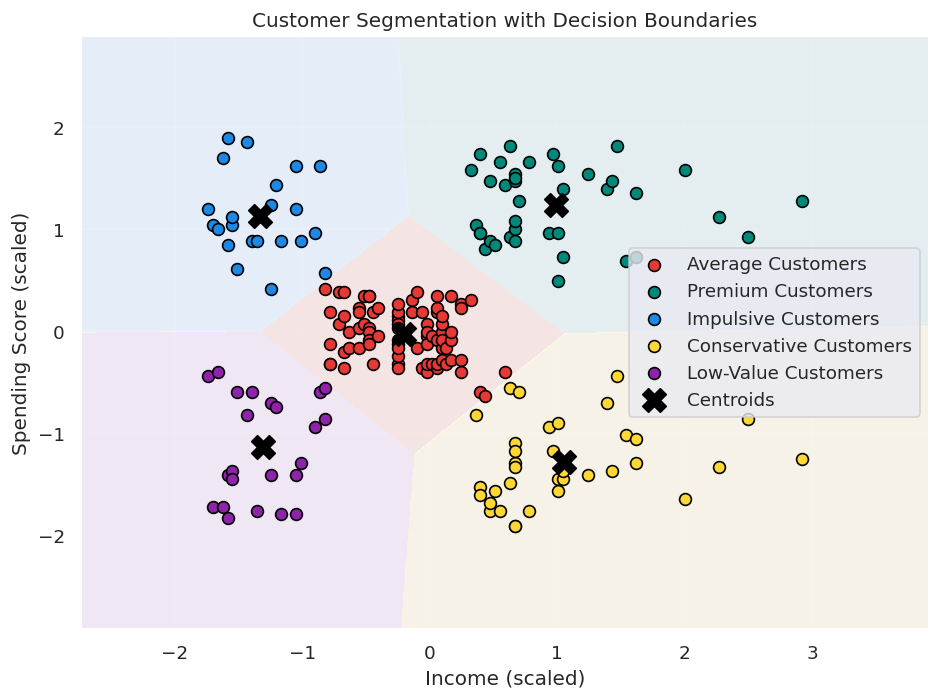

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap

# ---- Use 2 features (scaled) ----
X_plot = X_scaled

# ---- Train KMeans ----
kmeans_2d = KMeans(n_clusters=5, random_state=42)
labels = kmeans_2d.fit_predict(X_plot)

# ---- Create DataFrame for means ----
import pandas as pd
means = pd.DataFrame(X_plot, columns=['Income', 'Spending'])
means['Cluster'] = labels
means = means.groupby('Cluster').mean()

# ---- YOUR categorization logic ----
cluster_names = {}

for i in means.index:
    income = means.loc[i, 'Income']
    spending = means.loc[i, 'Spending']

    if income > 0.5 and spending > 0.5:
        cluster_names[i] = "Premium Customers"
    elif income > 0.5 and spending < -0.5:
        cluster_names[i] = "Conservative Customers"
    elif income < -0.5 and spending > 0.5:
        cluster_names[i] = "Impulsive Customers"
    elif income < -0.5 and spending < -0.5:
        cluster_names[i] = "Low-Value Customers"
    else:
        cluster_names[i] = "Average Customers"

# ---- Mesh grid (smooth boundaries) ----
h = 0.005
x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = kmeans_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# ---- Colors ----
cmap_light = ListedColormap(['#fde0dc','#e0f2f1','#e3f2fd','#fff8e1','#f3e5f5'])
cmap_bold = ListedColormap(['#e53935','#00897b','#1e88e5','#fdd835','#8e24aa'])

# ---- Plot ----
plt.figure(figsize=(8,6), dpi=120)

# Decision boundary
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6, levels=50)

# Points with legend
for i in range(kmeans_2d.n_clusters):
    plt.scatter(
        X_plot[labels == i, 0],
        X_plot[labels == i, 1],
        c=[cmap_bold(i)],
        label=cluster_names[i],
        edgecolor='black',
        s=50
    )

# Centroids
centers = kmeans_2d.cluster_centers_
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black', s=200, marker='X', label='Centroids'
)

# Labels
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Customer Segmentation with Decision Boundaries")

plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# **Example new customer**

In [133]:

# Format: [Income, Spending]
new_customer = [[70, 80]]

# Step 1: scale (IMPORTANT)
new_customer_scaled = scaler.transform(new_customer)

# Step 2: predict cluster
cluster = kmeans_2d.predict(new_customer_scaled)

print("Cluster:", cluster[0])
print("Category:", cluster_names[cluster[0]])

Cluster: 1
Category: Premium Customers


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
